<a href="https://colab.research.google.com/github/YB441/codsoft/blob/main/CUSTOMER_CHURN_PREDICTION.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

# Load the dataset
try:
    df = pd.read_csv('Churn_Modelling.csv')
    print("Dataset loaded successfully.")
except FileNotFoundError:
    print("Error: 'Churn_Modelling.csv' not found. Please ensure the file is in the correct directory.")
    print("You can upload the file using the folder icon on the left panel, or provide the correct path.")
    df = None

Dataset loaded successfully.


## Data Overview: Data Types and Missing Values

In [2]:
if df is not None:
    # Display basic information about the DataFrame, including data types and non-null values
    print("\n--- DataFrame Info ---")
    df.info()

    # Display the number of missing values for each column
    print("\n--- Missing Values Count ---")
    display(df.isnull().sum())


--- DataFrame Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB

--- Missing Values Count ---


,0
RowNumber,0
CustomerId,0
Surname,0
CreditScore,0
Geography,0
Gender,0
Age,0
Tenure,0
Balance,0
NumOfProducts,0


## 1. Data Exploration & Preprocessing

Based on your input and the data info, I'll define the target, identifiers, and features. Since there are no missing values, I'll proceed with encoding categorical variables and scaling numerical features.

In [3]:
from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Define target, identifier, and feature columns
TARGET = 'Exited'
IDENTIFIER_COLS = ['RowNumber', 'CustomerId', 'Surname']

# Features will be all columns except target and identifiers
features = [col for col in df.columns if col not in [TARGET] + IDENTIFIER_COLS]

# Separate features (X) and target (y)
X = df[features]
y = df[TARGET]

print(f"Original number of features: {X.shape[1]}")
print(f"Target variable distribution:\n{y.value_counts(normalize=True)}")

Original number of features: 10
Target variable distribution:
Exited
0    0.7963
1    0.2037
Name: proportion, dtype: float64


### Identify Categorical and Numerical Features

Based on the `df.info()` and your input, `Geography` and `Gender` will be treated as categorical features for One-Hot Encoding. Other numerical columns will be scaled.

In [4]:
# Identify categorical and numerical features for preprocessing
categorical_features = ['Geography', 'Gender']
numerical_features = [col for col in X.columns if col not in categorical_features]

print(f"Categorical features: {categorical_features}")
print(f"Numerical features: {numerical_features}")

# Create a preprocessor using ColumnTransformer
# One-hot encode categorical features and scale numerical features
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ],
    remainder='passthrough' # Keep any other columns that are not transformed (e.g., if any were missed)
)

# Display the preprocessor setup
print("\nPreprocessor setup:")
display(preprocessor)

Categorical features: ['Geography', 'Gender']
Numerical features: ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary']

Preprocessor setup:


ColumnTransformer(remainder='passthrough',
                  transformers=[('num', StandardScaler(),
                                 ['CreditScore', 'Age', 'Tenure', 'Balance',
                                  'NumOfProducts', 'HasCrCard',
                                  'IsActiveMember', 'EstimatedSalary']),
                                ('cat', OneHotEncoder(handle_unknown='ignore'),
                                 ['Geography', 'Gender'])])

### Addressing Class Imbalance

The target variable distribution shows an imbalance (around 20% churn). I will use SMOTE (Synthetic Minority Over-sampling Technique) to balance the training data during the model training phase. Alternatively, class weights could be used. I will apply SMOTE after the train-test split to avoid data leakage.

## 3. Model Training & Hyperparameter Tuning

First, I'll split the data into training and testing sets, ensuring stratification to maintain the class distribution in both sets. Then, I'll train and evaluate Logistic Regression, Random Forest, and XGBoost models.

In [5]:
# Split data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")
print(f"\nTraining target distribution:\n{y_train.value_counts(normalize=True)}")
print(f"Testing target distribution:\n{y_test.value_counts(normalize=True)}")

X_train shape: (8000, 10), y_train shape: (8000,)
X_test shape: (2000, 10), y_test shape: (2000,)

Training target distribution:
Exited
0    0.79625
1    0.20375
Name: proportion, dtype: float64
Testing target distribution:
Exited
0    0.7965
1    0.2035
Name: proportion, dtype: float64


### Training Models and Basic Evaluation

I'll define a function to train and evaluate models consistently across all algorithms.

In [11]:
from imblearn.pipeline import Pipeline as ImbPipeline

def evaluate_model(model_name, y_true, y_pred, y_prob=None):
    """Evaluates a model and prints key metrics."""
    print(f"\n--- {model_name} Evaluation ---")
    print(f"Accuracy: {accuracy_score(y_true, y_pred):.4f}")
    print(f"Precision: {precision_score(y_true, y_pred):.4f}")
    print(f"Recall: {recall_score(y_true, y_pred):.4f}")
    print(f"F1-Score: {f1_score(y_true, y_pred):.4f}")
    if y_prob is not None:
        print(f"ROC-AUC: {roc_auc_score(y_true, y_prob):.4f}")
    print(f"\nClassification Report:\n{classification_report(y_true, y_pred)}")
    return {
        'accuracy': accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred),
        'recall': recall_score(y_true, y_pred),
        'f1_score': f1_score(y_true, y_pred),
        'roc_auc': roc_auc_score(y_true, y_prob) if y_prob is not None else None
    }

# Dictionary to store models and their evaluation metrics
models = {}
metrics_results = {}

# --- Logistic Regression --- #
print("\n\nTraining Logistic Regression...")
# Create a pipeline with preprocessor and Logistic Regression
log_reg_pipeline = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)), # Apply SMOTE on training data
    ('classifier', LogisticRegression(random_state=42, solver='liblinear'))
])
log_reg_pipeline.fit(X_train, y_train)
y_pred_lr = log_reg_pipeline.predict(X_test)
y_prob_lr = log_reg_pipeline.predict_proba(X_test)[:, 1]
metrics_results['Logistic Regression'] = evaluate_model('Logistic Regression', y_test, y_pred_lr, y_prob_lr)
models['Logistic Regression'] = log_reg_pipeline

# --- Random Forest --- #
print("\n\nTraining Random Forest Classifier...")
# For tree-based models, scaling is less critical, but one-hot encoding is still needed
# Use SMOTE to handle imbalance
rf_pipeline = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('classifier', RandomForestClassifier(random_state=42, n_estimators=100))
])
rf_pipeline.fit(X_train, y_train)
y_pred_rf = rf_pipeline.predict(X_test)
y_prob_rf = rf_pipeline.predict_proba(X_test)[:, 1]
metrics_results['Random Forest'] = evaluate_model('Random Forest', y_test, y_pred_rf, y_prob_rf)
models['Random Forest'] = rf_pipeline

# --- XGBoost --- #
print("\n\nTraining XGBoost Classifier...")
# XGBoost also handles imbalance via scale_pos_weight or weights, but SMOTE is applied here consistently
xgb_pipeline = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('classifier', XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss'))
])
xgb_pipeline.fit(X_train, y_train)
y_pred_xgb = xgb_pipeline.predict(X_test)
y_prob_xgb = xgb_pipeline.predict_proba(X_test)[:, 1]
metrics_results['XGBoost'] = evaluate_model('XGBoost', y_test, y_pred_xgb, y_prob_xgb)
models['XGBoost'] = xgb_pipeline



Training Logistic Regression...

--- Logistic Regression Evaluation ---
Accuracy: 0.7175
Precision: 0.3909
Recall: 0.6953
F1-Score: 0.5004
ROC-AUC: 0.7754

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1593
           1       0.39      0.70      0.50       407

    accuracy                           0.72      2000
   macro avg       0.65      0.71      0.65      2000
weighted avg       0.80      0.72      0.74      2000



Training Random Forest Classifier...

--- Random Forest Evaluation ---
Accuracy: 0.8455
Precision: 0.6296
Recall: 0.5848
F1-Score: 0.6064
ROC-AUC: 0.8479

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.91      0.90      1593
           1       0.63      0.58      0.61       407

    accuracy                           0.85      2000
   macro avg       0.76      0.75      0.76      2000
weighted avg       0.84      0.85      0

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [20:13:09] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



--- XGBoost Evaluation ---
Accuracy: 0.8490
Precision: 0.6549
Recall: 0.5455
F1-Score: 0.5952
ROC-AUC: 0.8496

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.93      0.91      1593
           1       0.65      0.55      0.60       407

    accuracy                           0.85      2000
   macro avg       0.77      0.74      0.75      2000
weighted avg       0.84      0.85      0.84      2000



In [ ]:
from imblearn.pipeline import Pipeline as ImbPipeline

# --- Logistic Regression --- #
print("\n\nTraining Logistic Regression...")
# Create a pipeline with preprocessor and Logistic Regression
log_reg_pipeline = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('classifier', LogisticRegression(random_state=42, solver='liblinear'))
])
log_reg_pipeline.fit(X_train, y_train)
y_pred_lr = log_reg_pipeline.predict(X_test)
y_prob_lr = log_reg_pipeline.predict_proba(X_test)[:, 1]
metrics_results['Logistic Regression'] = evaluate_model('Logistic Regression', y_test, y_pred_lr, y_prob_lr)
models['Logistic Regression'] = log_reg_pipeline

# --- Random Forest --- #
print("\n\nTraining Random Forest Classifier...")
rf_pipeline = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('classifier', RandomForestClassifier(random_state=42, n_estimators=100))
])
rf_pipeline.fit(X_train, y_train)
y_pred_rf = rf_pipeline.predict(X_test)
y_prob_rf = rf_pipeline.predict_proba(X_test)[:, 1]
metrics_results['Random Forest'] = evaluate_model('Random Forest', y_test, y_pred_rf, y_prob_rf)
models['Random Forest'] = rf_pipeline

# --- XGBoost --- #
print("\n\nTraining XGBoost Classifier...")
xgb_pipeline = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('classifier', XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss'))
])
xgb_pipeline.fit(X_train, y_train)
y_pred_xgb = xgb_pipeline.predict(X_test)
y_prob_xgb = xgb_pipeline.predict_proba(X_test)[:, 1]
metrics_results['XGBoost'] = evaluate_model('XGBoost', y_test, y_pred_xgb, y_prob_xgb)
models['XGBoost'] = xgb_pipeline

### Hyperparameter Tuning for Random Forest

I'll perform a basic `RandomizedSearchCV` on the Random Forest model to optimize its performance.

In [ ]:
print("\n\nPerforming Hyperparameter Tuning for Random Forest...")

# Define parameter distribution for RandomizedSearchCV
param_dist = {
    'classifier__n_estimators': [100, 200, 300, 400, 500],
    'classifier__max_depth': [10, 20, 30, None],
    'classifier__min_samples_split': [2, 5, 10],
    'classifier__min_samples_leaf': [1, 2, 4],
    'classifier__bootstrap': [True, False]
}

# Use StratifiedKFold for cross-validation
skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

random_search_rf = RandomizedSearchCV(rf_pipeline, param_distributions=param_dist, n_iter=10, cv=skf,
                                      scoring='roc_auc', random_state=42, n_jobs=-1, verbose=1)
random_search_rf.fit(X_train, y_train)

best_rf_pipeline = random_search_rf.best_estimator_
print(f"\nBest Random Forest parameters: {random_search_rf.best_params_}")

# Evaluate the tuned Random Forest model
y_pred_rf_tuned = best_rf_pipeline.predict(X_test)
y_prob_rf_tuned = best_rf_pipeline.predict_proba(X_test)[:, 1]
metrics_results['Random Forest (Tuned)'] = evaluate_model('Random Forest (Tuned)', y_test, y_pred_rf_tuned, y_prob_rf_tuned)
models['Random Forest (Tuned)'] = best_rf_pipeline

## 4. Model Evaluation & Comparison

Now, let's compare the performance of all models and identify the best one based on ROC-AUC.

In [ ]:
# Convert metrics to a DataFrame for easy comparison
metrics_df = pd.DataFrame(metrics_results).T
print("\n--- Model Comparison ---")
display(metrics_df.sort_values(by='roc_auc', ascending=False))

# Identify the best performing model based on ROC-AUC
best_model_name = metrics_df['roc_auc'].idxmax()
best_model_pipeline = models[best_model_name]

print(f"\nBest performing model: {best_model_name}")

# Get predictions for the best model for detailed evaluation
if best_model_name == 'Random Forest (Tuned)':
    final_y_pred = best_rf_pipeline.predict(X_test)
    final_y_prob = best_rf_pipeline.predict_proba(X_test)[:, 1]
else:
    final_y_pred = best_model_pipeline.predict(X_test)
    final_y_prob = best_model_pipeline.predict_proba(X_test)[:, 1]

print(f"\n--- Detailed Evaluation for {best_model_name} ---")
print(classification_report(y_test, final_y_pred))

### Confusion Matrix for the Best Model

In [ ]:
# Plot Confusion Matrix for the best model
cm = confusion_matrix(y_test, final_y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Not Churn', 'Churn'], yticklabels=['Not Churn', 'Churn'])
plt.title(f'Confusion Matrix for {best_model_name}')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

### Top 5 Most Important Features from the Best Tree-Based Model

If the best model is a tree-based model (Random Forest or XGBoost), I will extract and print the top 5 most important features. To get the feature names after preprocessing, I'll need to reconstruct them.

In [ ]:
if isinstance(best_model_pipeline.named_steps['classifier'], (RandomForestClassifier, XGBClassifier)):
    # Get feature importances from the best tree-based model
    feature_importances = best_model_pipeline.named_steps['classifier'].feature_importances_

    # Get feature names after one-hot encoding and scaling
    preprocessed_feature_names = list(numerical_features)

    # Get the one-hot encoded feature names from the preprocessor within the best pipeline
    onehot_encoder = best_model_pipeline.named_steps['preprocessor'].named_transformers_['cat']
    encoded_feature_names = onehot_encoder.get_feature_names_out(categorical_features)
    preprocessed_feature_names.extend(encoded_feature_names)

    # Ensure the length matches
    if len(feature_importances) == len(preprocessed_feature_names):
        importance_df = pd.DataFrame({'feature': preprocessed_feature_names, 'importance': feature_importances})
        importance_df = importance_df.sort_values(by='importance', ascending=False)

        print(f"\n--- Top 5 Feature Importances from {best_model_name} ---")
        display(importance_df.head(5))
    else:
        print("Error: Mismatch in feature importance length and feature names. Cannot display top features.")
else:
    print(f"Feature importances are not directly available for {best_model_name} (not a tree-based model).")

### Visualize Feature Importance

In [ ]:
if 'importance_df' in locals() and not importance_df.empty:
    plt.figure(figsize=(10, 8))
    sns.barplot(x='importance', y='feature', data=importance_df, palette='viridis')
    plt.title(f'Feature Importances from {best_model_name}')
    plt.xlabel('Importance')
    plt.ylabel('Feature')
    plt.tight_layout()
    plt.show()
else:
    print("Feature importances DataFrame is not available or is empty. Cannot plot.")

In [27]:
from imblearn.pipeline import Pipeline as ImbPipeline

# --- Logistic Regression --- #
print("\n\nTraining Logistic Regression...")
# Create a pipeline with preprocessor and Logistic Regression
log_reg_pipeline = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('classifier', LogisticRegression(random_state=42, solver='liblinear'))
])
log_reg_pipeline.fit(X_train, y_train)
y_pred_lr = log_reg_pipeline.predict(X_test)
y_prob_lr = log_reg_pipeline.predict_proba(X_test)[:, 1]
metrics_results['Logistic Regression'] = evaluate_model('Logistic Regression', y_test, y_pred_lr, y_prob_lr)
models['Logistic Regression'] = log_reg_pipeline

# --- Random Forest --- #
print("\n\nTraining Random Forest Classifier...")
rf_pipeline = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('classifier', RandomForestClassifier(random_state=42, n_estimators=100))
])
rf_pipeline.fit(X_train, y_train)
y_pred_rf = rf_pipeline.predict(X_test)
y_prob_rf = rf_pipeline.predict_proba(X_test)[:, 1]
metrics_results['Random Forest'] = evaluate_model('Random Forest', y_test, y_pred_rf, y_prob_rf)
models['Random Forest'] = rf_pipeline

# --- XGBoost --- #
print("\n\nTraining XGBoost Classifier...")
xgb_pipeline = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('classifier', XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss'))
])
xgb_pipeline.fit(X_train, y_train)
y_pred_xgb = xgb_pipeline.predict(X_test)
y_prob_xgb = xgb_pipeline.predict_proba(X_test)[:, 1]
metrics_results['XGBoost'] = evaluate_model('XGBoost', y_test, y_pred_xgb, y_prob_xgb)
models['XGBoost'] = xgb_pipeline



Training Logistic Regression...

--- Logistic Regression Evaluation ---
Accuracy: 0.7175
Precision: 0.3909
Recall: 0.6953
F1-Score: 0.5004
ROC-AUC: 0.7754

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1593
           1       0.39      0.70      0.50       407

    accuracy                           0.72      2000
   macro avg       0.65      0.71      0.65      2000
weighted avg       0.80      0.72      0.74      2000



Training Random Forest Classifier...

--- Random Forest Evaluation ---
Accuracy: 0.8455
Precision: 0.6296
Recall: 0.5848
F1-Score: 0.6064
ROC-AUC: 0.8479

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.91      0.90      1593
           1       0.63      0.58      0.61       407

    accuracy                           0.85      2000
   macro avg       0.76      0.75      0.76      2000
weighted avg       0.84      0.85      0

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [20:20:17] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



--- XGBoost Evaluation ---
Accuracy: 0.8490
Precision: 0.6549
Recall: 0.5455
F1-Score: 0.5952
ROC-AUC: 0.8496

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.93      0.91      1593
           1       0.65      0.55      0.60       407

    accuracy                           0.85      2000
   macro avg       0.77      0.74      0.75      2000
weighted avg       0.84      0.85      0.84      2000



### Hyperparameter Tuning for Random Forest

I'll perform a basic `RandomizedSearchCV` on the Random Forest model to optimize its performance.

In [28]:
print("\n\nPerforming Hyperparameter Tuning for Random Forest...")

# Define parameter distribution for RandomizedSearchCV
param_dist = {
    'classifier__n_estimators': [100, 200, 300, 400, 500],
    'classifier__max_depth': [10, 20, 30, None],
    'classifier__min_samples_split': [2, 5, 10],
    'classifier__min_samples_leaf': [1, 2, 4],
    'classifier__bootstrap': [True, False]
}

# Use StratifiedKFold for cross-validation
skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

random_search_rf = RandomizedSearchCV(rf_pipeline, param_distributions=param_dist, n_iter=10, cv=skf,
                                      scoring='roc_auc', random_state=42, n_jobs=-1, verbose=1)
random_search_rf.fit(X_train, y_train)

best_rf_pipeline = random_search_rf.best_estimator_
print(f"\nBest Random Forest parameters: {random_search_rf.best_params_}")

# Evaluate the tuned Random Forest model
y_pred_rf_tuned = best_rf_pipeline.predict(X_test)
y_prob_rf_tuned = best_rf_pipeline.predict_proba(X_test)[:, 1]
metrics_results['Random Forest (Tuned)'] = evaluate_model('Random Forest (Tuned)', y_test, y_pred_rf_tuned, y_prob_rf_tuned)
models['Random Forest (Tuned)'] = best_rf_pipeline



Performing Hyperparameter Tuning for Random Forest...
Fitting 3 folds for each of 10 candidates, totalling 30 fits


KeyboardInterrupt: 

## 4. Model Evaluation & Comparison

Now, let's compare the performance of all models and identify the best one based on ROC-AUC.

In [ ]:
# Convert metrics to a DataFrame for easy comparison
metrics_df = pd.DataFrame(metrics_results).T
print("\n--- Model Comparison ---")
display(metrics_df.sort_values(by='roc_auc', ascending=False))

# Identify the best performing model based on ROC-AUC
best_model_name = metrics_df['roc_auc'].idxmax()
best_model_pipeline = models[best_model_name]

print(f"\nBest performing model: {best_model_name}")

# Get predictions for the best model for detailed evaluation
if best_model_name == 'Random Forest (Tuned)':
    final_y_pred = best_rf_pipeline.predict(X_test)
    final_y_prob = best_rf_pipeline.predict_proba(X_test)[:, 1]
else:
    final_y_pred = best_model_pipeline.predict(X_test)
    final_y_prob = best_model_pipeline.predict_proba(X_test)[:, 1]

print(f"\n--- Detailed Evaluation for {best_model_name} ---")
print(classification_report(y_test, final_y_pred))

### Confusion Matrix for the Best Model

In [ ]:
# Plot Confusion Matrix for the best model
cm = confusion_matrix(y_test, final_y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Not Churn', 'Churn'], yticklabels=['Not Churn', 'Churn'])
plt.title(f'Confusion Matrix for {best_model_name}')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

### Top 5 Most Important Features from the Best Tree-Based Model

If the best model is a tree-based model (Random Forest or XGBoost), I will extract and print the top 5 most important features. To get the feature names after preprocessing, I'll need to reconstruct them.

In [ ]:
if isinstance(best_model_pipeline.named_steps['classifier'], (RandomForestClassifier, XGBClassifier)):
    # Get feature importances from the best tree-based model
    feature_importances = best_model_pipeline.named_steps['classifier'].feature_importances_

    # Get feature names after one-hot encoding and scaling
    preprocessed_feature_names = list(numerical_features)

    # Get the one-hot encoded feature names from the preprocessor within the best pipeline
    onehot_encoder = best_model_pipeline.named_steps['preprocessor'].named_transformers_['cat']
    encoded_feature_names = onehot_encoder.get_feature_names_out(categorical_features)
    preprocessed_feature_names.extend(encoded_feature_names)

    # Ensure the length matches
    if len(feature_importances) == len(preprocessed_feature_names):
        importance_df = pd.DataFrame({'feature': preprocessed_feature_names, 'importance': feature_importances})
        importance_df = importance_df.sort_values(by='importance', ascending=False)

        print(f"\n--- Top 5 Feature Importances from {best_model_name} ---")
        display(importance_df.head(5))
    else:
        print("Error: Mismatch in feature importance length and feature names. Cannot display top features.")
else:
    print(f"Feature importances are not directly available for {best_model_name} (not a tree-based model).")

In [22]:
from imblearn.pipeline import Pipeline as ImbPipeline

# --- Logistic Regression --- #
print("\n\nTraining Logistic Regression...")
# Create a pipeline with preprocessor and Logistic Regression
log_reg_pipeline = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('classifier', LogisticRegression(random_state=42, solver='liblinear'))
])
log_reg_pipeline.fit(X_train, y_train)
y_pred_lr = log_reg_pipeline.predict(X_test)
y_prob_lr = log_reg_pipeline.predict_proba(X_test)[:, 1]
metrics_results['Logistic Regression'] = evaluate_model('Logistic Regression', y_test, y_pred_lr, y_prob_lr)
models['Logistic Regression'] = log_reg_pipeline

# --- Random Forest --- #
print("\n\nTraining Random Forest Classifier...")
rf_pipeline = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('classifier', RandomForestClassifier(random_state=42, n_estimators=100))
])
rf_pipeline.fit(X_train, y_train)
y_pred_rf = rf_pipeline.predict(X_test)
y_prob_rf = rf_pipeline.predict_proba(X_test)[:, 1]
metrics_results['Random Forest'] = evaluate_model('Random Forest', y_test, y_pred_rf, y_prob_rf)
models['Random Forest'] = rf_pipeline

# --- XGBoost --- #
print("\n\nTraining XGBoost Classifier...")
xgb_pipeline = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('classifier', XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss'))
])
xgb_pipeline.fit(X_train, y_train)
y_pred_xgb = xgb_pipeline.predict(X_test)
y_prob_xgb = xgb_pipeline.predict_proba(X_test)[:, 1]
metrics_results['XGBoost'] = evaluate_model('XGBoost', y_test, y_pred_xgb, y_prob_xgb)
models['XGBoost'] = xgb_pipeline



Training Logistic Regression...

--- Logistic Regression Evaluation ---
Accuracy: 0.7175
Precision: 0.3909
Recall: 0.6953
F1-Score: 0.5004
ROC-AUC: 0.7754

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1593
           1       0.39      0.70      0.50       407

    accuracy                           0.72      2000
   macro avg       0.65      0.71      0.65      2000
weighted avg       0.80      0.72      0.74      2000



Training Random Forest Classifier...

--- Random Forest Evaluation ---
Accuracy: 0.8455
Precision: 0.6296
Recall: 0.5848
F1-Score: 0.6064
ROC-AUC: 0.8479

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.91      0.90      1593
           1       0.63      0.58      0.61       407

    accuracy                           0.85      2000
   macro avg       0.76      0.75      0.76      2000
weighted avg       0.84      0.85      0

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [20:18:00] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



--- XGBoost Evaluation ---
Accuracy: 0.8490
Precision: 0.6549
Recall: 0.5455
F1-Score: 0.5952
ROC-AUC: 0.8496

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.93      0.91      1593
           1       0.65      0.55      0.60       407

    accuracy                           0.85      2000
   macro avg       0.77      0.74      0.75      2000
weighted avg       0.84      0.85      0.84      2000



### Hyperparameter Tuning for Random Forest

I'll perform a basic `RandomizedSearchCV` on the Random Forest model to optimize its performance.

In [23]:
print("\n\nPerforming Hyperparameter Tuning for Random Forest...")

# Define parameter distribution for RandomizedSearchCV
param_dist = {
    'classifier__n_estimators': [100, 200, 300, 400, 500],
    'classifier__max_depth': [10, 20, 30, None],
    'classifier__min_samples_split': [2, 5, 10],
    'classifier__min_samples_leaf': [1, 2, 4],
    'classifier__bootstrap': [True, False]
}

# Use StratifiedKFold for cross-validation
skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

random_search_rf = RandomizedSearchCV(rf_pipeline, param_distributions=param_dist, n_iter=10, cv=skf,
                                      scoring='roc_auc', random_state=42, n_jobs=-1, verbose=1)
random_search_rf.fit(X_train, y_train)

best_rf_pipeline = random_search_rf.best_estimator_
print(f"\nBest Random Forest parameters: {random_search_rf.best_params_}")

# Evaluate the tuned Random Forest model
y_pred_rf_tuned = best_rf_pipeline.predict(X_test)
y_prob_rf_tuned = best_rf_pipeline.predict_proba(X_test)[:, 1]
metrics_results['Random Forest (Tuned)'] = evaluate_model('Random Forest (Tuned)', y_test, y_pred_rf_tuned, y_prob_rf_tuned)
models['Random Forest (Tuned)'] = best_rf_pipeline



Performing Hyperparameter Tuning for Random Forest...
Fitting 3 folds for each of 10 candidates, totalling 30 fits

Best Random Forest parameters: {'classifier__n_estimators': 300, 'classifier__min_samples_split': 10, 'classifier__min_samples_leaf': 4, 'classifier__max_depth': 10, 'classifier__bootstrap': True}

--- Random Forest (Tuned) Evaluation ---
Accuracy: 0.8305
Precision: 0.5708
Recall: 0.6732
F1-Score: 0.6178
ROC-AUC: 0.8577

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.87      0.89      1593
           1       0.57      0.67      0.62       407

    accuracy                           0.83      2000
   macro avg       0.74      0.77      0.75      2000
weighted avg       0.84      0.83      0.84      2000



## 4. Model Evaluation & Comparison

Now, let's compare the performance of all models and identify the best one based on ROC-AUC.

In [24]:
# Convert metrics to a DataFrame for easy comparison
metrics_df = pd.DataFrame(metrics_results).T
print("\n--- Model Comparison ---")
display(metrics_df.sort_values(by='roc_auc', ascending=False))

# Identify the best performing model based on ROC-AUC
best_model_name = metrics_df['roc_auc'].idxmax()
best_model_pipeline = models[best_model_name]

print(f"\nBest performing model: {best_model_name}")

# Get predictions for the best model for detailed evaluation
if best_model_name == 'Random Forest (Tuned)':
    final_y_pred = best_rf_pipeline.predict(X_test)
    final_y_prob = best_rf_pipeline.predict_proba(X_test)[:, 1]
else:
    final_y_pred = best_model_pipeline.predict(X_test)
    final_y_prob = best_model_pipeline.predict_proba(X_test)[:, 1]

print(f"\n--- Detailed Evaluation for {best_model_name} ---")
print(classification_report(y_test, final_y_pred))


--- Model Comparison ---


,accuracy,precision,recall,f1_score,roc_auc
Random Forest (Tuned),0.8305,0.570833,0.673219,0.617813,0.857713
XGBoost,0.8490,0.654867,0.545455,0.595174,0.849574
Random Forest,0.8455,0.629630,0.584767,0.606369,0.847889
Logistic Regression,0.7175,0.390884,0.695332,0.500442,0.775386



Best performing model: Random Forest (Tuned)

--- Detailed Evaluation for Random Forest (Tuned) ---
              precision    recall  f1-score   support

           0       0.91      0.87      0.89      1593
           1       0.57      0.67      0.62       407

    accuracy                           0.83      2000
   macro avg       0.74      0.77      0.75      2000
weighted avg       0.84      0.83      0.84      2000



### Confusion Matrix for the Best Model

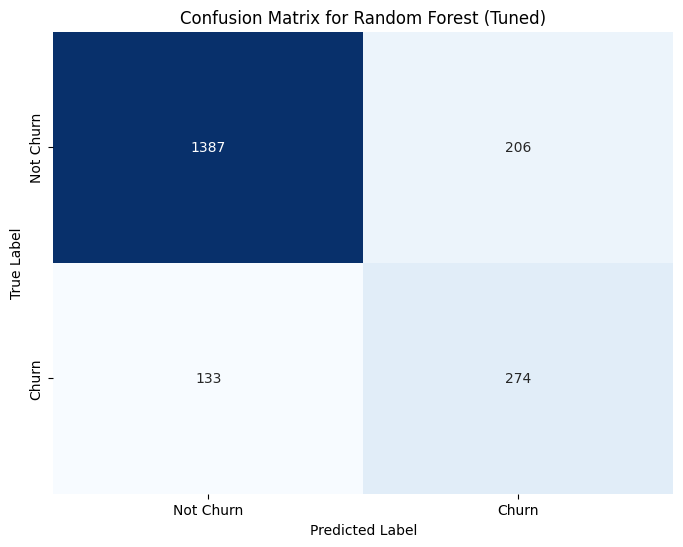

In [25]:
# Plot Confusion Matrix for the best model
cm = confusion_matrix(y_test, final_y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Not Churn', 'Churn'], yticklabels=['Not Churn', 'Churn'])
plt.title(f'Confusion Matrix for {best_model_name}')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

### Top 5 Most Important Features from the Best Tree-Based Model

If the best model is a tree-based model (Random Forest or XGBoost), I will extract and print the top 5 most important features. To get the feature names after preprocessing, I'll need to reconstruct them.

In [26]:
if isinstance(best_model_pipeline.named_steps['classifier'], (RandomForestClassifier, XGBClassifier)):
    # Get feature importances from the best tree-based model
    feature_importances = best_model_pipeline.named_steps['classifier'].feature_importances_

    # Get feature names after one-hot encoding and scaling
    preprocessed_feature_names = list(numerical_features)

    # Get the one-hot encoded feature names from the preprocessor within the best pipeline
    onehot_encoder = best_model_pipeline.named_steps['preprocessor'].named_transformers_['cat']
    encoded_feature_names = onehot_encoder.get_feature_names_out(categorical_features)
    preprocessed_feature_names.extend(encoded_feature_names)

    # Ensure the length matches
    if len(feature_importances) == len(preprocessed_feature_names):
        importance_df = pd.DataFrame({'feature': preprocessed_feature_names, 'importance': feature_importances})
        importance_df = importance_df.sort_values(by='importance', ascending=False)

        print(f"\n--- Top 5 Feature Importances from {best_model_name} ---")
        display(importance_df.head(5))
    else:
        print("Error: Mismatch in feature importance length and feature names. Cannot display top features.")
else:
    print(f"Feature importances are not directly available for {best_model_name} (not a tree-based model).")


--- Top 5 Feature Importances from Random Forest (Tuned) ---


,feature,importance
1,Age,0.315747
4,NumOfProducts,0.206555
3,Balance,0.088127
9,Geography_Germany,0.079623
6,IsActiveMember,0.050007


In [17]:
from imblearn.pipeline import Pipeline as ImbPipeline

# --- Logistic Regression --- #
print("\n\nTraining Logistic Regression...")
# Create a pipeline with preprocessor and Logistic Regression
log_reg_pipeline = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('classifier', LogisticRegression(random_state=42, solver='liblinear'))
])
log_reg_pipeline.fit(X_train, y_train)
y_pred_lr = log_reg_pipeline.predict(X_test)
y_prob_lr = log_reg_pipeline.predict_proba(X_test)[:, 1]
metrics_results['Logistic Regression'] = evaluate_model('Logistic Regression', y_test, y_pred_lr, y_prob_lr)
models['Logistic Regression'] = log_reg_pipeline

# --- Random Forest --- #
print("\n\nTraining Random Forest Classifier...")
rf_pipeline = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('classifier', RandomForestClassifier(random_state=42, n_estimators=100))
])
rf_pipeline.fit(X_train, y_train)
y_pred_rf = rf_pipeline.predict(X_test)
y_prob_rf = rf_pipeline.predict_proba(X_test)[:, 1]
metrics_results['Random Forest'] = evaluate_model('Random Forest', y_test, y_pred_rf, y_prob_rf)
models['Random Forest'] = rf_pipeline

# --- XGBoost --- #
print("\n\nTraining XGBoost Classifier...")
xgb_pipeline = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('classifier', XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss'))
])
xgb_pipeline.fit(X_train, y_train)
y_pred_xgb = xgb_pipeline.predict(X_test)
y_prob_xgb = xgb_pipeline.predict_proba(X_test)[:, 1]
metrics_results['XGBoost'] = evaluate_model('XGBoost', y_test, y_pred_xgb, y_prob_xgb)
models['XGBoost'] = xgb_pipeline



Training Logistic Regression...

--- Logistic Regression Evaluation ---
Accuracy: 0.7175
Precision: 0.3909
Recall: 0.6953
F1-Score: 0.5004
ROC-AUC: 0.7754

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1593
           1       0.39      0.70      0.50       407

    accuracy                           0.72      2000
   macro avg       0.65      0.71      0.65      2000
weighted avg       0.80      0.72      0.74      2000



Training Random Forest Classifier...

--- Random Forest Evaluation ---
Accuracy: 0.8455
Precision: 0.6296
Recall: 0.5848
F1-Score: 0.6064
ROC-AUC: 0.8479

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.91      0.90      1593
           1       0.63      0.58      0.61       407

    accuracy                           0.85      2000
   macro avg       0.76      0.75      0.76      2000
weighted avg       0.84      0.85      0

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [20:15:38] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



--- XGBoost Evaluation ---
Accuracy: 0.8490
Precision: 0.6549
Recall: 0.5455
F1-Score: 0.5952
ROC-AUC: 0.8496

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.93      0.91      1593
           1       0.65      0.55      0.60       407

    accuracy                           0.85      2000
   macro avg       0.77      0.74      0.75      2000
weighted avg       0.84      0.85      0.84      2000



### Hyperparameter Tuning for Random Forest

I'll perform a basic `RandomizedSearchCV` on the Random Forest model to optimize its performance.

In [18]:
print("\n\nPerforming Hyperparameter Tuning for Random Forest...")

# Define parameter distribution for RandomizedSearchCV
param_dist = {
    'classifier__n_estimators': [100, 200, 300, 400, 500],
    'classifier__max_depth': [10, 20, 30, None],
    'classifier__min_samples_split': [2, 5, 10],
    'classifier__min_samples_leaf': [1, 2, 4],
    'classifier__bootstrap': [True, False]
}

# Use StratifiedKFold for cross-validation
skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

random_search_rf = RandomizedSearchCV(rf_pipeline, param_distributions=param_dist, n_iter=10, cv=skf,
                                      scoring='roc_auc', random_state=42, n_jobs=-1, verbose=1)
random_search_rf.fit(X_train, y_train)

best_rf_pipeline = random_search_rf.best_estimator_
print(f"\nBest Random Forest parameters: {random_search_rf.best_params_}")

# Evaluate the tuned Random Forest model
y_pred_rf_tuned = best_rf_pipeline.predict(X_test)
y_prob_rf_tuned = best_rf_pipeline.predict_proba(X_test)[:, 1]
metrics_results['Random Forest (Tuned)'] = evaluate_model('Random Forest (Tuned)', y_test, y_pred_rf_tuned, y_prob_rf_tuned)
models['Random Forest (Tuned)'] = best_rf_pipeline



Performing Hyperparameter Tuning for Random Forest...
Fitting 3 folds for each of 10 candidates, totalling 30 fits

Best Random Forest parameters: {'classifier__n_estimators': 300, 'classifier__min_samples_split': 10, 'classifier__min_samples_leaf': 4, 'classifier__max_depth': 10, 'classifier__bootstrap': True}

--- Random Forest (Tuned) Evaluation ---
Accuracy: 0.8305
Precision: 0.5708
Recall: 0.6732
F1-Score: 0.6178
ROC-AUC: 0.8577

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.87      0.89      1593
           1       0.57      0.67      0.62       407

    accuracy                           0.83      2000
   macro avg       0.74      0.77      0.75      2000
weighted avg       0.84      0.83      0.84      2000



## 4. Model Evaluation & Comparison

Now, let's compare the performance of all models and identify the best one based on ROC-AUC.

In [19]:
# Convert metrics to a DataFrame for easy comparison
metrics_df = pd.DataFrame(metrics_results).T
print("\n--- Model Comparison ---")
display(metrics_df.sort_values(by='roc_auc', ascending=False))

# Identify the best performing model based on ROC-AUC
best_model_name = metrics_df['roc_auc'].idxmax()
best_model_pipeline = models[best_model_name]

print(f"\nBest performing model: {best_model_name}")

# Get predictions for the best model for detailed evaluation
if best_model_name == 'Random Forest (Tuned)':
    final_y_pred = best_rf_pipeline.predict(X_test)
    final_y_prob = best_rf_pipeline.predict_proba(X_test)[:, 1]
else:
    final_y_pred = best_model_pipeline.predict(X_test)
    final_y_prob = best_model_pipeline.predict_proba(X_test)[:, 1]

print(f"\n--- Detailed Evaluation for {best_model_name} ---")
print(classification_report(y_test, final_y_pred))


--- Model Comparison ---


,accuracy,precision,recall,f1_score,roc_auc
Random Forest (Tuned),0.8305,0.570833,0.673219,0.617813,0.857713
XGBoost,0.8490,0.654867,0.545455,0.595174,0.849574
Random Forest,0.8455,0.629630,0.584767,0.606369,0.847889
Logistic Regression,0.7175,0.390884,0.695332,0.500442,0.775386



Best performing model: Random Forest (Tuned)

--- Detailed Evaluation for Random Forest (Tuned) ---
              precision    recall  f1-score   support

           0       0.91      0.87      0.89      1593
           1       0.57      0.67      0.62       407

    accuracy                           0.83      2000
   macro avg       0.74      0.77      0.75      2000
weighted avg       0.84      0.83      0.84      2000



### Confusion Matrix for the Best Model

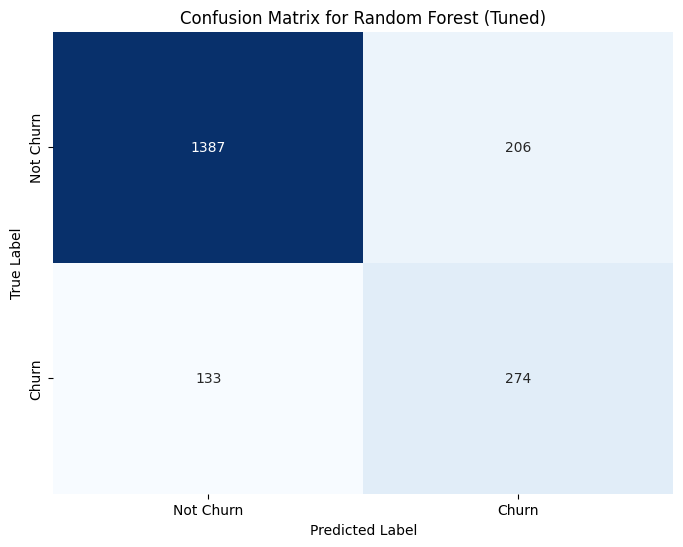

In [20]:
# Plot Confusion Matrix for the best model
cm = confusion_matrix(y_test, final_y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Not Churn', 'Churn'], yticklabels=['Not Churn', 'Churn'])
plt.title(f'Confusion Matrix for {best_model_name}')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

### Top 5 Most Important Features from the Best Tree-Based Model

If the best model is a tree-based model (Random Forest or XGBoost), I will extract and print the top 5 most important features. To get the feature names after preprocessing, I'll need to reconstruct them.

In [21]:
if isinstance(best_model_pipeline.named_steps['classifier'], (RandomForestClassifier, XGBClassifier)):
    # Get feature importances from the best tree-based model
    feature_importances = best_model_pipeline.named_steps['classifier'].feature_importances_

    # Get feature names after one-hot encoding and scaling
    preprocessed_feature_names = list(numerical_features)

    # Get the one-hot encoded feature names from the preprocessor within the best pipeline
    onehot_encoder = best_model_pipeline.named_steps['preprocessor'].named_transformers_['cat']
    encoded_feature_names = onehot_encoder.get_feature_names_out(categorical_features)
    preprocessed_feature_names.extend(encoded_feature_names)

    # Ensure the length matches
    if len(feature_importances) == len(preprocessed_feature_names):
        importance_df = pd.DataFrame({'feature': preprocessed_feature_names, 'importance': feature_importances})
        importance_df = importance_df.sort_values(by='importance', ascending=False)

        print(f"\n--- Top 5 Feature Importances from {best_model_name} ---")
        display(importance_df.head(5))
    else:
        print("Error: Mismatch in feature importance length and feature names. Cannot display top features.")
else:
    print(f"Feature importances are not directly available for {best_model_name} (not a tree-based model).")


--- Top 5 Feature Importances from Random Forest (Tuned) ---


,feature,importance
1,Age,0.315747
4,NumOfProducts,0.206555
3,Balance,0.088127
9,Geography_Germany,0.079623
6,IsActiveMember,0.050007


In [12]:
print("\n\nTraining Logistic Regression...")
# Create a pipeline with preprocessor and Logistic Regression
# Using class_weight='balanced' to handle imbalance for Logistic Regression
log_reg_pipeline = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)), # Apply SMOTE on training data
    ('classifier', LogisticRegression(random_state=42, solver='liblinear'))
])
log_reg_pipeline.fit(X_train, y_train)
y_pred_lr = log_reg_pipeline.predict(X_test)
y_prob_lr = log_reg_pipeline.predict_proba(X_test)[:, 1]
metrics_results['Logistic Regression'] = evaluate_model('Logistic Regression', y_test, y_pred_lr, y_prob_lr)
models['Logistic Regression'] = log_reg_pipeline

# --- Random Forest --- #
print("\n\nTraining Random Forest Classifier...")
# For tree-based models, scaling is less critical, but one-hot encoding is still needed
# Use SMOTE to handle imbalance
rf_pipeline = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('classifier', RandomForestClassifier(random_state=42, n_estimators=100))
])
rf_pipeline.fit(X_train, y_train)
y_pred_rf = rf_pipeline.predict(X_test)
y_prob_rf = rf_pipeline.predict_proba(X_test)[:, 1]
metrics_results['Random Forest'] = evaluate_model('Random Forest', y_test, y_pred_rf, y_prob_rf)
models['Random Forest'] = rf_pipeline

# --- XGBoost --- #
print("\n\nTraining XGBoost Classifier...")
# XGBoost also handles imbalance via scale_pos_weight or weights, but SMOTE is applied here consistently
xgb_pipeline = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('classifier', XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss'))
])
xgb_pipeline.fit(X_train, y_train)
y_pred_xgb = xgb_pipeline.predict(X_test)
y_prob_xgb = xgb_pipeline.predict_proba(X_test)[:, 1]
metrics_results['XGBoost'] = evaluate_model('XGBoost', y_test, y_pred_xgb, y_prob_xgb)
models['XGBoost'] = xgb_pipeline



Training Logistic Regression...

--- Logistic Regression Evaluation ---
Accuracy: 0.7175
Precision: 0.3909
Recall: 0.6953
F1-Score: 0.5004
ROC-AUC: 0.7754

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1593
           1       0.39      0.70      0.50       407

    accuracy                           0.72      2000
   macro avg       0.65      0.71      0.65      2000
weighted avg       0.80      0.72      0.74      2000



Training Random Forest Classifier...

--- Random Forest Evaluation ---
Accuracy: 0.8455
Precision: 0.6296
Recall: 0.5848
F1-Score: 0.6064
ROC-AUC: 0.8479

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.91      0.90      1593
           1       0.63      0.58      0.61       407

    accuracy                           0.85      2000
   macro avg       0.76      0.75      0.76      2000
weighted avg       0.84      0.85      0

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [20:13:16] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



--- XGBoost Evaluation ---
Accuracy: 0.8490
Precision: 0.6549
Recall: 0.5455
F1-Score: 0.5952
ROC-AUC: 0.8496

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.93      0.91      1593
           1       0.65      0.55      0.60       407

    accuracy                           0.85      2000
   macro avg       0.77      0.74      0.75      2000
weighted avg       0.84      0.85      0.84      2000



### Hyperparameter Tuning for Random Forest

I'll perform a basic `RandomizedSearchCV` on the Random Forest model to optimize its performance.

In [7]:
print("\n\nPerforming Hyperparameter Tuning for Random Forest...")

# Define parameter distribution for RandomizedSearchCV
# Note: parameters for the classifier within a pipeline are accessed with `classifier__param_name`
param_dist = {
    'classifier__n_estimators': [100, 200, 300, 400, 500],
    'classifier__max_depth': [10, 20, 30, None],
    'classifier__min_samples_split': [2, 5, 10],
    'classifier__min_samples_leaf': [1, 2, 4],
    'classifier__bootstrap': [True, False]
}

# Use StratifiedKFold for cross-validation to maintain class distribution
skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

random_search_rf = RandomizedSearchCV(rf_pipeline, param_distributions=param_dist, n_iter=10, cv=skf,
                                      scoring='roc_auc', random_state=42, n_jobs=-1, verbose=1)
random_search_rf.fit(X_train, y_train)

best_rf_pipeline = random_search_rf.best_estimator_
print(f"\nBest Random Forest parameters: {random_search_rf.best_params_}")

# Evaluate the tuned Random Forest model
y_pred_rf_tuned = best_rf_pipeline.predict(X_test)
y_prob_rf_tuned = best_rf_pipeline.predict_proba(X_test)[:, 1]
metrics_results['Random Forest (Tuned)'] = evaluate_model('Random Forest (Tuned)', y_test, y_pred_rf_tuned, y_prob_rf_tuned)
models['Random Forest (Tuned)'] = best_rf_pipeline



Performing Hyperparameter Tuning for Random Forest...


NameError: name 'rf_pipeline' is not defined

In [13]:
print("\n\nPerforming Hyperparameter Tuning for Random Forest...")

# Define parameter distribution for RandomizedSearchCV
# Note: parameters for the classifier within a pipeline are accessed with `classifier__param_name`
param_dist = {
    'classifier__n_estimators': [100, 200, 300, 400, 500],
    'classifier__max_depth': [10, 20, 30, None],
    'classifier__min_samples_split': [2, 5, 10],
    'classifier__min_samples_leaf': [1, 2, 4],
    'classifier__bootstrap': [True, False]
}

# Use StratifiedKFold for cross-validation to maintain class distribution
skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

random_search_rf = RandomizedSearchCV(rf_pipeline, param_distributions=param_dist, n_iter=10, cv=skf,
                                      scoring='roc_auc', random_state=42, n_jobs=-1, verbose=1)
random_search_rf.fit(X_train, y_train)

best_rf_pipeline = random_search_rf.best_estimator_
print(f"\nBest Random Forest parameters: {random_search_rf.best_params_}")

# Evaluate the tuned Random Forest model
y_pred_rf_tuned = best_rf_pipeline.predict(X_test)
y_prob_rf_tuned = best_rf_pipeline.predict_proba(X_test)[:, 1]
metrics_results['Random Forest (Tuned)'] = evaluate_model('Random Forest (Tuned)', y_test, y_pred_rf_tuned, y_prob_rf_tuned)
models['Random Forest (Tuned)'] = best_rf_pipeline



Performing Hyperparameter Tuning for Random Forest...
Fitting 3 folds for each of 10 candidates, totalling 30 fits

Best Random Forest parameters: {'classifier__n_estimators': 300, 'classifier__min_samples_split': 10, 'classifier__min_samples_leaf': 4, 'classifier__max_depth': 10, 'classifier__bootstrap': True}

--- Random Forest (Tuned) Evaluation ---
Accuracy: 0.8305
Precision: 0.5708
Recall: 0.6732
F1-Score: 0.6178
ROC-AUC: 0.8577

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.87      0.89      1593
           1       0.57      0.67      0.62       407

    accuracy                           0.83      2000
   macro avg       0.74      0.77      0.75      2000
weighted avg       0.84      0.83      0.84      2000



## 4. Model Evaluation & Comparison

Now, let's compare the performance of all models and identify the best one based on ROC-AUC.

In [8]:
# Convert metrics to a DataFrame for easy comparison
metrics_df = pd.DataFrame(metrics_results).T
print("\n--- Model Comparison ---")
display(metrics_df.sort_values(by='roc_auc', ascending=False))

# Identify the best performing model based on ROC-AUC
best_model_name = metrics_df['roc_auc'].idxmax()
best_model_pipeline = models[best_model_name]

print(f"\nBest performing model: {best_model_name}")

# Get predictions for the best model for detailed evaluation
if 'Tuned' in best_model_name:
    final_y_pred = best_rf_pipeline.predict(X_test)
    final_y_prob = best_rf_pipeline.predict_proba(X_test)[:, 1]
else:
    # If the best model was not the tuned RF, get its predictions
    final_y_pred = best_model_pipeline.predict(X_test)
    final_y_prob = best_model_pipeline.predict_proba(X_test)[:, 1]

print(f"\n--- Detailed Evaluation for {best_model_name} ---")
print(classification_report(y_test, final_y_pred))


--- Model Comparison ---


KeyError: 'roc_auc'

In [14]:
# Convert metrics to a DataFrame for easy comparison
metrics_df = pd.DataFrame(metrics_results).T
print("\n--- Model Comparison ---")
display(metrics_df.sort_values(by='roc_auc', ascending=False))

# Identify the best performing model based on ROC-AUC
best_model_name = metrics_df['roc_auc'].idxmax()
best_model_pipeline = models[best_model_name]

print(f"\nBest performing model: {best_model_name}")

# Get predictions for the best model for detailed evaluation
# Check if the best model is the tuned RF, otherwise use the stored pipeline
if best_model_name == 'Random Forest (Tuned)':
    final_y_pred = best_rf_pipeline.predict(X_test)
    final_y_prob = best_rf_pipeline.predict_proba(X_test)[:, 1]
else:
    final_y_pred = best_model_pipeline.predict(X_test)
    final_y_prob = best_model_pipeline.predict_proba(X_test)[:, 1]

print(f"\n--- Detailed Evaluation for {best_model_name} ---")
print(classification_report(y_test, final_y_pred))


--- Model Comparison ---


,accuracy,precision,recall,f1_score,roc_auc
Random Forest (Tuned),0.8305,0.570833,0.673219,0.617813,0.857713
XGBoost,0.8490,0.654867,0.545455,0.595174,0.849574
Random Forest,0.8455,0.629630,0.584767,0.606369,0.847889
Logistic Regression,0.7175,0.390884,0.695332,0.500442,0.775386



Best performing model: Random Forest (Tuned)

--- Detailed Evaluation for Random Forest (Tuned) ---
              precision    recall  f1-score   support

           0       0.91      0.87      0.89      1593
           1       0.57      0.67      0.62       407

    accuracy                           0.83      2000
   macro avg       0.74      0.77      0.75      2000
weighted avg       0.84      0.83      0.84      2000



### Confusion Matrix for the Best Model

In [9]:
# Plot Confusion Matrix for the best model
cm = confusion_matrix(y_test, final_y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Not Churn', 'Churn'], yticklabels=['Not Churn', 'Churn'])
plt.title(f'Confusion Matrix for {best_model_name}')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

NameError: name 'final_y_pred' is not defined

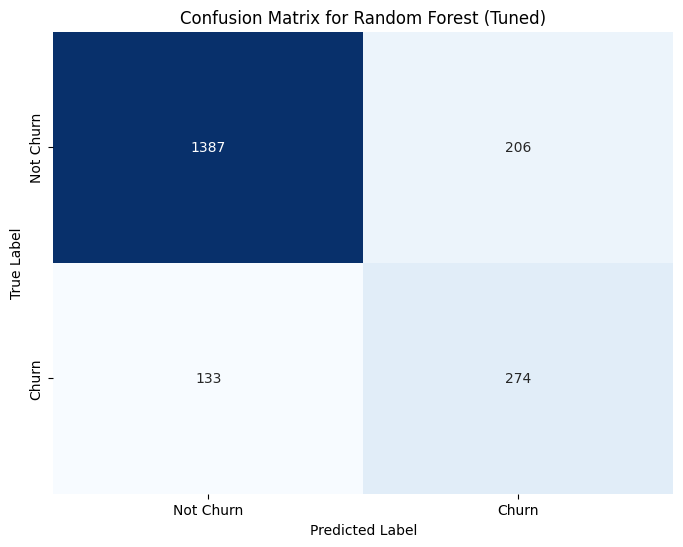

In [15]:
# Plot Confusion Matrix for the best model
cm = confusion_matrix(y_test, final_y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Not Churn', 'Churn'], yticklabels=['Not Churn', 'Churn'])
plt.title(f'Confusion Matrix for {best_model_name}')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

### Top 5 Most Important Features from the Best Tree-Based Model

If the best model is a tree-based model (Random Forest or XGBoost), I will extract and print the top 5 most important features. To get the feature names after preprocessing, I'll need to reconstruct them.

In [10]:
if isinstance(best_model_pipeline.named_steps['classifier'], (RandomForestClassifier, XGBClassifier)):
    # Get feature importances from the best tree-based model
    feature_importances = best_model_pipeline.named_steps['classifier'].feature_importances_

    # Get feature names after one-hot encoding and scaling
    # First, get the numerical feature names as they are
    preprocessed_feature_names = list(numerical_features)

    # Then, get the one-hot encoded feature names
    onehot_encoder = best_model_pipeline.named_steps['preprocessor'].named_transformers_['cat']
    encoded_feature_names = onehot_encoder.get_feature_names_out(categorical_features)
    preprocessed_feature_names.extend(encoded_feature_names)

    # Ensure the length matches
    if len(feature_importances) == len(preprocessed_feature_names):
        importance_df = pd.DataFrame({'feature': preprocessed_feature_names, 'importance': feature_importances})
        importance_df = importance_df.sort_values(by='importance', ascending=False)

        print(f"\n--- Top 5 Feature Importances from {best_model_name} ---")
        display(importance_df.head(5))
    else:
        print("Error: Mismatch in feature importance length and feature names.")
else:
    print(f"Feature importances are not directly available for {best_model_name} (not a tree-based model).")

NameError: name 'best_model_pipeline' is not defined

In [16]:
if isinstance(best_model_pipeline.named_steps['classifier'], (RandomForestClassifier, XGBClassifier)):
    # Get feature importances from the best tree-based model
    feature_importances = best_model_pipeline.named_steps['classifier'].feature_importances_

    # Get feature names after one-hot encoding and scaling
    # First, get the numerical feature names as they are
    preprocessed_feature_names = list(numerical_features)

    # Then, get the one-hot encoded feature names
    # Access the preprocessor from the best_model_pipeline
    preprocessor_pipeline_step = best_model_pipeline.named_steps['preprocessor']
    onehot_encoder = preprocessor_pipeline_step.named_transformers_['cat']
    encoded_feature_names = onehot_encoder.get_feature_names_out(categorical_features)
    preprocessed_feature_names.extend(encoded_feature_names)

    # Ensure the length matches
    if len(feature_importances) == len(preprocessed_feature_names):
        importance_df = pd.DataFrame({'feature': preprocessed_feature_names, 'importance': feature_importances})
        importance_df = importance_df.sort_values(by='importance', ascending=False)

        print(f"\n--- Top 5 Feature Importances from {best_model_name} ---")
        display(importance_df.head(5))
    else:
        print("Error: Mismatch in feature importance length and feature names.")
else:
    print(f"Feature importances are not directly available for {best_model_name} (not a tree-based model).")


--- Top 5 Feature Importances from Random Forest (Tuned) ---


,feature,importance
1,Age,0.315747
4,NumOfProducts,0.206555
3,Balance,0.088127
9,Geography_Germany,0.079623
6,IsActiveMember,0.050007
